In [1]:
import sys
import os

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q
    os.kill(os.getpid(), 9)  # force runtime restart

# Курс по прогнозированию временных рядов

# Неделя 3.

# Определение периода сезонности временного ряда

Данные находятся в свободном доступе на портале [portal](https://open.ottawa.ca/search?collection=Dataset&q=service), предлагаемом городом Оттава. Портал утверждает следующее относительно этих данных.

Данные представляют собой сводку запросов на обслуживание, требующих действий со стороны городского персонала. Данные представлены по округам и показывают ответственный городской департамент и описание запроса на обслуживание.

Загрузим эти данные за 2019-2022 год.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Выгрузки Ottawa лежат в репозитории сжатыми (csv.gz) — pandas распаковывает
# их на лету, отдельного шага не нужно.
file_path = "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/SR-2019.csv.gz"
records2019 = pd.read_csv(file_path)

file_path = "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/SR-2020.csv.gz"
records2020 = pd.read_csv(file_path)

file_path = "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/2021_Monthly_Service_Requests_EN.csv.gz"
records2021 = pd.read_csv(file_path)

file_path = "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/2022_Monthly_Service_Requests.csv.gz"
records2022 = pd.read_csv(file_path)

Объединим четыре датафрейма в один.

In [3]:
records = pd.concat([records2019, records2020, records2021, records2022], axis=0)

# Данных по дням

Здесь мы агрегируем запросы на обслуживание за каждый день и получим новый набор данных для дальнейшей обработки. Построим график целиком и увеличенную часть графика.

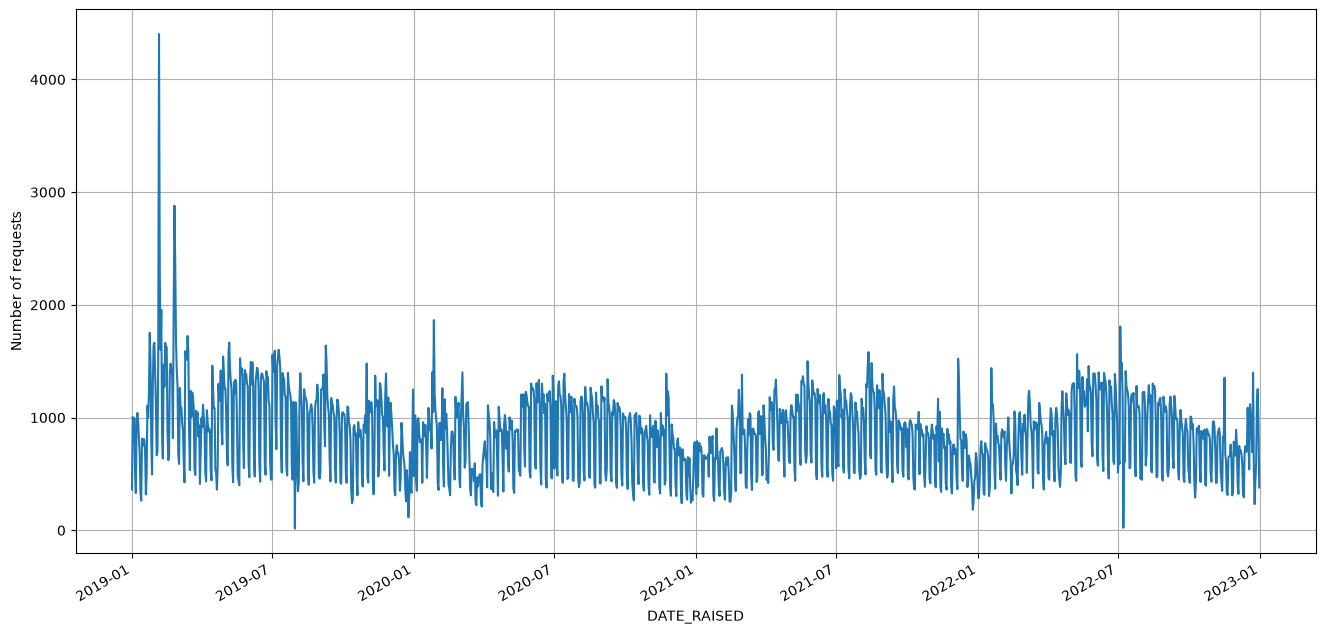

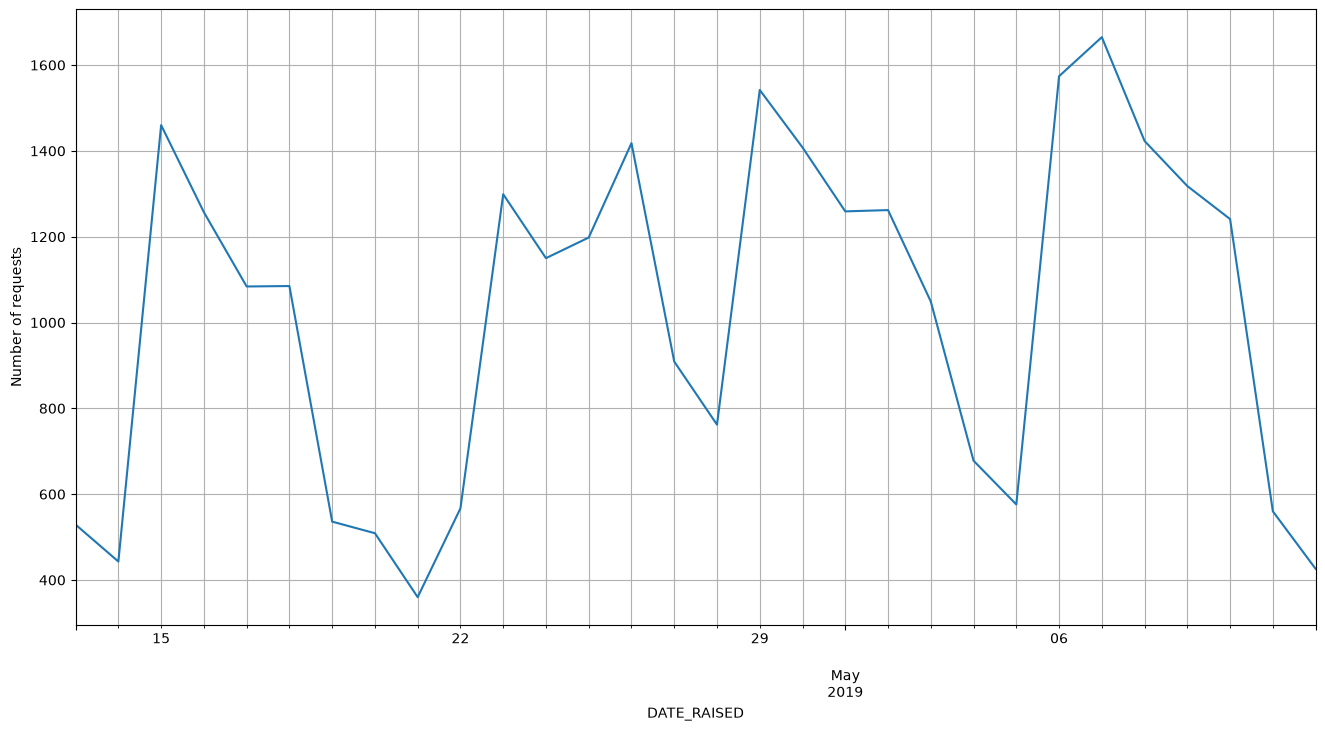

In [4]:
records["DATE_RAISED"] = pd.to_datetime(records.DATE_RAISED)
record_by_date = records.groupby("DATE_RAISED")["TYPE"].count().sort_index()
record_by_date.plot(figsize=(16, 8))
plt.ylabel("Number of requests")
plt.grid(visible=True, which="both")
plt.figure()

record_by_date.iloc[100:130].plot(figsize=(16, 8))
plt.ylabel("Number of requests")
plt.grid(visible=True, which="both")

## Проверка на отсутствие пропущенных дат

In [5]:
start_date = record_by_date.index.min()
end_date = record_by_date.index.max()

# create a complete date range for the period of interest
date_range = pd.date_range(start=start_date, end=end_date, freq="D")

# compare the date range to the index of the time series
missing_dates = date_range[~date_range.isin(record_by_date.index)]

if len(missing_dates) > 0:
    print("Missing dates:", missing_dates)
else:
    print("No missing dates")

Missing dates: DatetimeIndex(['2019-01-31', '2019-03-31', '2021-12-31', '2022-10-31'], dtype='datetime64[ns]', freq=None)


В нашем временном ряду есть 3 пропущенные даты. Добавим эти данные в индекс и заполним их средним значением соседних дат.

In [6]:
# Reindex to fill missing dates
idx = pd.date_range(start=record_by_date.index.min(), end=record_by_date.index.max(), freq="D")
record_by_date = record_by_date.reindex(idx, fill_value=0)

# Add missing dates with average of surrounding values
for date in missing_dates:
    prev_date = date - pd.DateOffset(days=1)
    next_date = date + pd.DateOffset(days=1)
    prev_val = record_by_date.loc[prev_date] if prev_date in record_by_date.index else np.nan
    next_val = record_by_date.loc[next_date] if next_date in record_by_date.index else np.nan
    avg_val = np.nanmean([prev_val, next_val])
    record_by_date.loc[date] = avg_val

/var/folders/p_/lhmc40f91qn_m64frv3rrz6h0000gq/T/ipykernel_89233/415934553.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1394.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  record_by_date.loc[date] = avg_val


## Поиск периодичности

Теперь попробуем определить период этого временного ряда. Мы ожидаем увидеть в наших данных период в семь дней. 

Из приведенного выше графика кажется, что существует недельная периодичность. Например, минимальные значения наблюдаются 14, 21 и 28 мая. Удивительно, но эти дни соответствуют вторникам. Теперь попробуем обнаружить эту периодичность автоматически.

## Автокорреляционный анализ

Построим график ACF. 

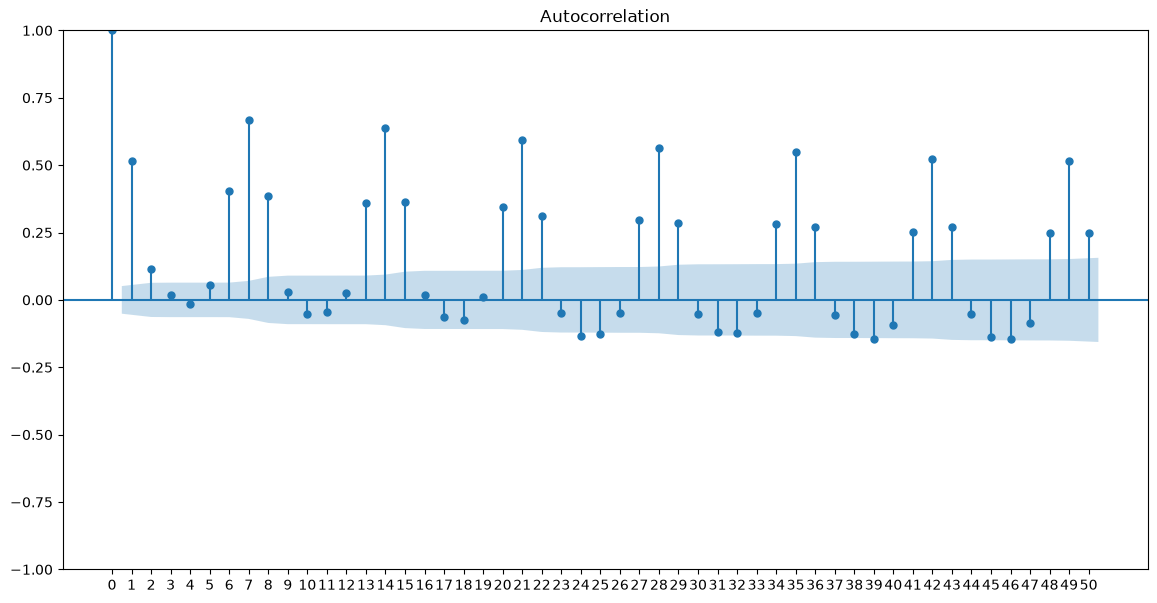

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14, 7))
plot_acf(record_by_date.values.squeeze(), lags=50, ax=ax, title="Autocorrelation", use_vlines=True)
lags = list(range(51))
ax.set_xticks(lags)
ax.set_xticklabels(lags);

Из приведенного выше графика видно, что имеются пики в 7, 14, 21 и т.д. дней. Это подтверждает, что наш временной ряд имеет период 7 дней.

## Анализ Фурье

Временная область и частотная область
- Представление во временной области: как сигнал изменяется с течением времени
- Представление в частотной области: какая часть сигнала лежит в определенном диапазоне частот

Здесь мы выполняем преобразование Фурье временного ряда и ищем доминирующую частотную составляющую. Обратная величина доминирующей частоты дает оценку периода сезонной компоненты.

Преобразование Фурье - это математическая операция, которая разлагает сложный сигнал на набор более простых синусоидальных и косинусоидальных волн. Преобразование Фурье позволяет анализировать сигналы и манипулировать ими в частотной области, что часто является более естественным и интуитивным способом работы с сигналами, чем во временной области.

<center>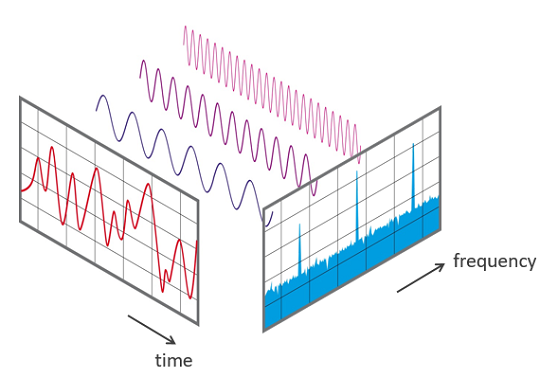</center>
<center> На рисунке представлен ряд = сумме трех переодических компонент

<center>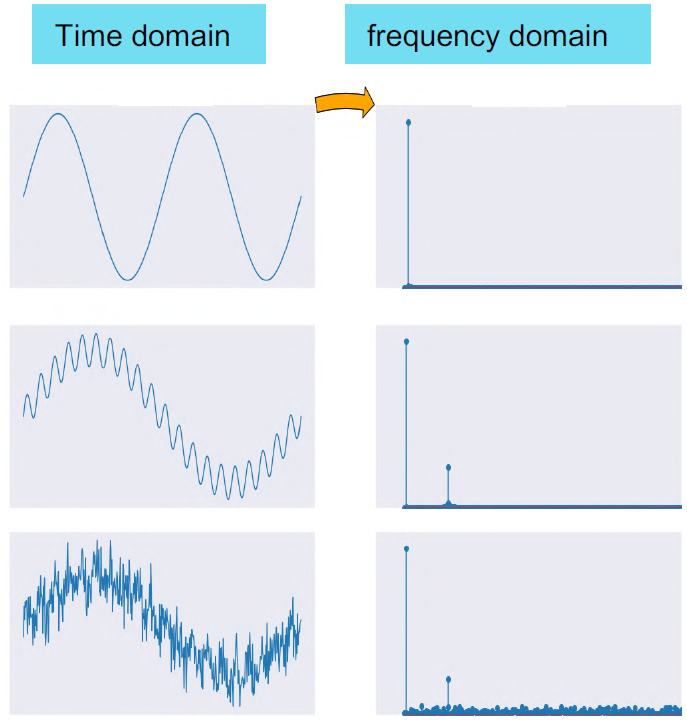</center>

In [8]:
# Вычислим преобразование Фурье
yf = np.fft.fft(record_by_date)
xf = np.linspace(0.0, 1.0 / (2.0), len(record_by_date) // 2)

# Найдите доминирующую частоту
# Мы должны отбросить первый элемент fft, так как он соответствует
# постоянной составляющей или среднему значению сигнала
idx = np.argmax(np.abs(yf[1 : len(record_by_date) // 2]))
freq = xf[idx]

period = 1 / freq
print(f"The period of the time series is {period}")

The period of the time series is 7.009615384615385


## Методы на основе периодограмм

Периодограмма - это график спектральной плотности мощности (Power Spectral Density) сигнала или последовательности. Другими словами, это график, показывающий, какая часть общей мощности сигнала содержится в каждой частоте. Периодограмма получается путем вычисления квадрата величины преобразования Фурье сигнала и широко используется в обработке сигналов и спектральном анализе.

The period of the time series is 6.990430622009569


np.float64(0.1430527036276523)

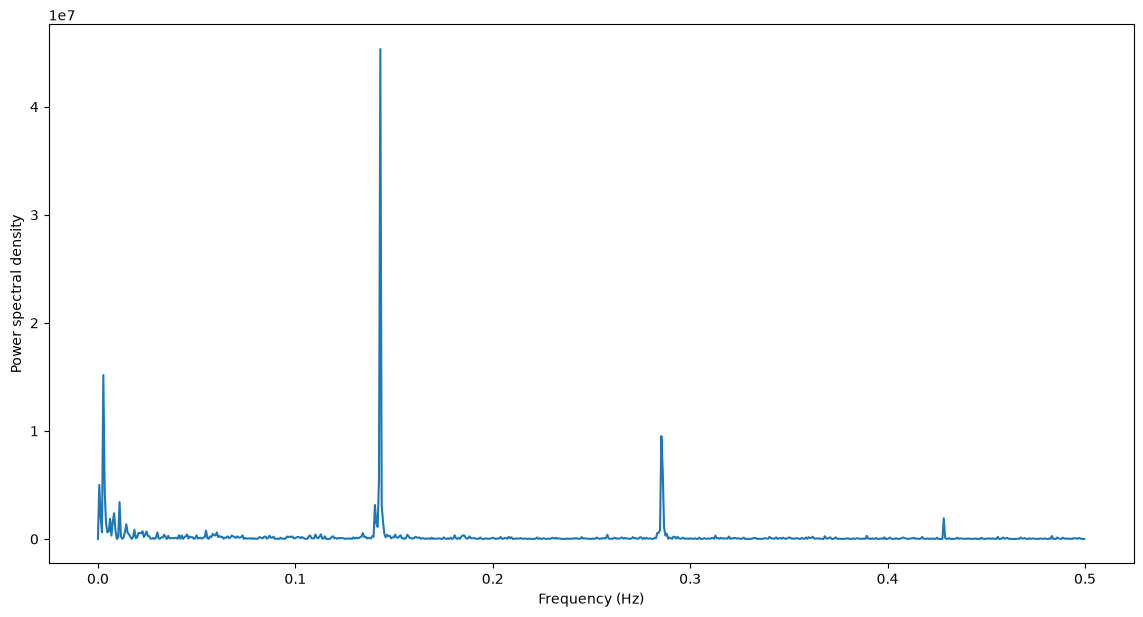

In [9]:
from scipy.signal import periodogram

freq, power = periodogram(record_by_date)
period = 1 / freq[np.argmax(power)]
print(f"The period of the time series is {period}")

plt.figure(figsize=(14, 7))
plt.plot(freq, power)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
freq[np.argmax(power)]

Сочетание временной и частотной обработки для обнаружения периодичности
- Плюсы: более точные, чем методы, использующие только временную/частотную область, такие как ACF, FFT
- Минусы: трудно обрабатывать многочисленные периодичности в сложных временных рядах

Подробнее смотри Michail Vlachos, Philip Yu, and Vittorio Castelli. 2005. On periodicity detection and structural periodic similarity.
In Proceedings of the 2005 SIAM International Conference on Data Mining (SDM), pp. 449–460, 2005.

https://epubs.siam.org/doi/10.1137/1.9781611972757.40

Надежное и общее обнаружение периодичности: RobustPeriod

- Ключевая идея: сначала выделите периодические компоненты, а затем надежно определите каждую из них («разделяй и властвуй»)
- Три блока: предварительная обработка, разделение нескольких периодичностей, надежное обнаружение одной периодичности

<center><img src="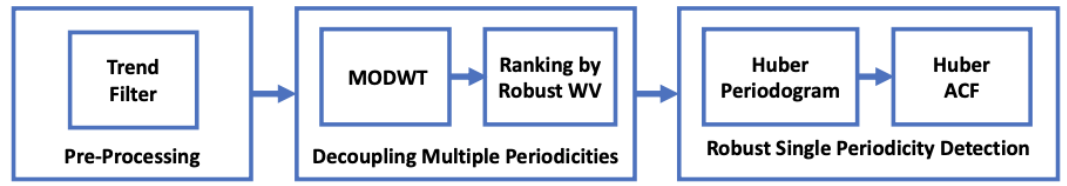
" width="800" align="center"></center>

Qingsong Wen, Kai He, Liang Sun, Yingying Zhang, Min Ke, Huan Xu, "RobustPeriod: Time-Frequency Mining for Robust Multiple Periodicity Detection,"
in Proc. ACM SIGMOD International Conference on Management of Data (SIGMOD 2021), Xi'an, China, Jun. 2021.

https://arxiv.org/abs/2002.09535